In [30]:
import faiss
import os
import pickle
import numpy as np
import random
import torch
from transformers import TimesformerModel, TimesformerConfig
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from pathlib import Path
from tqdm import tqdm
from video_processing import load_video_frames_opencv, extract_embedding
from tqdm import tqdm
from collections import Counter

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
faiss_index_path = r"embeddings/faiss_ucf101.index"
faiss_index = faiss.read_index(faiss_index_path)
with open(r"embeddings/embedding_map.pkl", "rb") as f:
    label2id = pickle.load(f)

In [4]:
config = TimesformerConfig.from_pretrained("facebook/timesformer-base-finetuned-k400")
model = TimesformerModel.from_pretrained(
    "facebook/timesformer-base-finetuned-k400",
    trust_remote_code=True,
    use_safetensors=True)
model.eval().to(device)

TimesformerModel(
  (embeddings): TimesformerEmbeddings(
    (patch_embeddings): TimesformerPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (time_drop): Dropout(p=0.0, inplace=False)
  )
  (encoder): TimesformerEncoder(
    (layer): ModuleList(
      (0-11): 12 x TimesformerLayer(
        (drop_path): Identity()
        (attention): TimeSformerAttention(
          (attention): TimesformerSelfAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
          )
          (output): TimesformerSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): TimesformerIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (dropout): Dropout(p=0.0, inpla

In [5]:
video_folder = "UCF101/test"
test_paths = []
for root, _, files in os.walk(video_folder):
    for f in files:
        if f.endswith((".mp4", ".avi")):
            test_paths.append(os.path.join(root, f))
test_paths = test_paths[:10]
len(test_paths)

10

In [6]:
def get_label(path):
  path = Path(path)
  return path.parts[2]

In [7]:
k_vals = [1, 3, 5]
all_top_labels = []

In [9]:
all_recalls= []
for k in k_vals:
    recalls = []
    all_top_labels = []
    for video_path in tqdm(test_paths):
        frames = load_video_frames_opencv(video_path)  
        emb = extract_embedding(frames, model, device)
        emb = emb.astype('float32')  

        D, I = faiss_index.search(emb, k)

        top_paths = [label2id.get(idx, None) for idx in I[0]]
        top_labels = [get_label(path) if path else None for path in top_paths]
        all_top_labels.append(top_labels)

        ground_truth_label = get_label(video_path)

        correct = sum(1 for label in top_labels if label == ground_truth_label)
        recall = correct / k
        recalls.append(recall)
    combined_recall = np.mean(recalls)
    print(f"Combined recall@{k}: {combined_recall:.4f}")
    all_recalls.append(combined_recall)
print("Recall@1: {:.4f}".format(all_recalls[0]))
print("Recall@3: {:.4f}".format(all_recalls[1]))
print("Recall@5: {:.4f}".format(all_recalls[2]))

100%|██████████| 10/10 [00:02<00:00,  4.85it/s]


Combined recall@1: 1.0000


100%|██████████| 10/10 [00:02<00:00,  4.85it/s]


Combined recall@3: 0.9667


100%|██████████| 10/10 [00:02<00:00,  4.88it/s]

Combined recall@5: 0.9600
Recall@1: 1.0000
Recall@3: 0.9667
Recall@5: 0.9600


In [14]:
labels = []
for i in sorted(label2id.keys()):
    path = label2id[i]
    class_name = get_label(path)
    labels.append(class_name)

In [15]:
embeddings = []
for i in range(faiss_index.ntotal):
    vector = faiss_index.reconstruct(i)
    embeddings.append(vector)

In [16]:
embeddings = np.array(embeddings)
assert len(labels) == embeddings.shape[0], "Labels and embeddings count mismatch"

In [17]:
def reduce_dimensionality(embeddings, n_components=2):
    reducer = TSNE(n_components=n_components, random_state=42, perplexity=30)
    return reducer.fit_transform(embeddings)

In [31]:
label_counts = Counter(labels)
selected_labels = random.sample(list(label_counts.keys()), min(10, len(label_counts)))

In [34]:
selected_indices = [i for i, label in enumerate(labels) if label in selected_labels]
sampled_embeddings = embeddings[selected_indices]
sampled_labels = [labels[i] for i in selected_indices]
print(f"Selected clusters: {selected_labels}")
print(f"Samples per cluster: {Counter(sampled_labels)}")

Selected clusters: ['WritingOnBoard', 'PushUps', 'BreastStroke', 'Hammering', 'ShavingBeard', 'MilitaryParade', 'TrampolineJumping', 'CricketShot', 'BasketballDunk', 'CricketBowling']
Samples per cluster: Counter({'CricketShot': 125, 'ShavingBeard': 120, 'WritingOnBoard': 114, 'Hammering': 105, 'CricketBowling': 104, 'BasketballDunk': 98, 'MilitaryParade': 93, 'TrampolineJumping': 89, 'PushUps': 76, 'BreastStroke': 75})


In [41]:
def visualize_clusters(embeddings_dict, labels, title):
    plt.figure(figsize=(20, 10))
    for idx, (method, emb_list) in enumerate(embeddings_dict.items()):
        reduced = reduce_dimensionality(np.array(emb_list))
        plt.subplot(1, 3, idx + 1)
        sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, 
                       s=40, palette="tab10", alpha=0.8)
        plt.title(f"{title} - {method.upper()} Pooling")
        plt.xlabel("t-SNE Dim 1")
        plt.ylabel("t-SNE Dim 2")
    plt.tight_layout()
    plt.show()

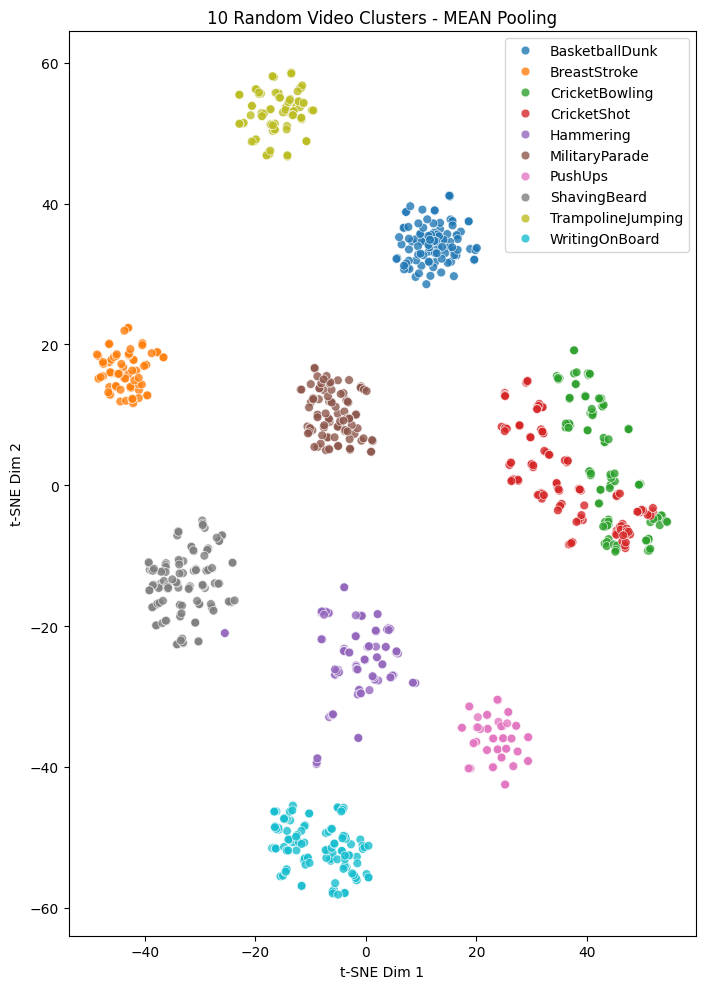

In [42]:
embeddings_dict = {"mean": sampled_embeddings}
visualize_clusters(embeddings_dict, sampled_labels, "10 Random Video Clusters")